In [ ]:
from dataclasses import dataclass
from zoneinfo import ZoneInfo
import numpy as np
import pandas as pd
import wrds

SPX_SECID = 108105

NY = ZoneInfo("America/New_York")

MINUTES_IN_DAY = 24 * 60
MINUTES_IN_YEAR = 525_600
N30 = 30 * MINUTES_IN_DAY

CALC_HOUR_ET = 16
CALC_MINUTE_ET = 00
EXPIRY_AM_HOUR_ET = 9
EXPIRY_AM_MINUTE_ET = 30
EXPIRY_PM_HOUR_ET = 16
EXPIRY_PM_MINUTE_ET = 0

# Eligibility window: >23 days and <37 days
N_MIN = 23 * MINUTES_IN_DAY
N_MAX = 37 * MINUTES_IN_DAY


def _require(cond: bool, msg: str) -> None:
    if not cond:
        raise ValueError(msg)

@dataclass(frozen=True)
class PreparedChain:
    calls: pd.DataFrame  # index=strike, cols: bid, ask, mid
    puts: pd.DataFrame   # index=strike, cols: bid, ask, mid
    strikes: np.ndarray  # sorted common strikes (both sides)


def prepare_chain(chain: pd.DataFrame) -> PreparedChain:
    """
      - Normalize cp_flag to {C,P}
      - Drop rows with null strike/bid/ask
      - Enforce strike > 0, bid>=0, ask>=0
      - Exclude rows with bid > ask
      - Enforce uniqueness per (cp_flag, strike)
      - Remove strikes with null quotes from BOTH series by intersecting call+put strike sets
      - Compute mid = (bid+ask)/2
    """
    cols = ["strike", "cp_flag", "bid", "ask"]

    df = chain.loc[:, cols].copy()
    df["cp_flag"] = df["cp_flag"].astype(str).str.upper()
    df = df[df["cp_flag"].isin(["C", "P"])]

    df = df.dropna(subset=["strike", "bid", "ask"])
    df["strike"] = pd.to_numeric(df["strike"], errors="coerce")
    df["bid"] = pd.to_numeric(df["bid"], errors="coerce")
    df["ask"] = pd.to_numeric(df["ask"], errors="coerce")
    df = df.dropna(subset=["strike", "bid", "ask"])

    df = df[(df["strike"] > 0) & (df["bid"] >= 0) & (df["ask"] >= 0)]
    df = df[df["bid"] <= df["ask"]]

    dup = df.duplicated(subset=["cp_flag", "strike"], keep=False)
    _require(not dup.any(), "Duplicate rows for (cp_flag, strike); must deduplicate upstream to be spec-exact.")

    calls = (
        df[df["cp_flag"] == "C"]
        .set_index("strike", verify_integrity=True)[["bid", "ask"]]
        .sort_index()
    )
    puts = (
        df[df["cp_flag"] == "P"]
        .set_index("strike", verify_integrity=True)[["bid", "ask"]]
        .sort_index()
    )

    # Spec step: remove strikes with null quotes from BOTH series -> keep only common strikes
    common_strikes = calls.index.intersection(puts.index)
    _require(len(common_strikes) > 0, "No strikes with BOTH call and put quotes after spec filtering.")
    calls = calls.loc[common_strikes].copy()
    puts = puts.loc[common_strikes].copy()

    calls["mid"] = 0.5 * (calls["bid"] + calls["ask"])
    puts["mid"] = 0.5 * (puts["bid"] + puts["ask"])

    strikes = common_strikes.to_numpy(dtype=float)
    return PreparedChain(calls=calls, puts=puts, strikes=strikes)


@dataclass(frozen=True)
class TermResult:
    minutes_to_expiry: int
    T: float
    R: float
    K_atm: float
    F: float
    K0: float
    sigma2: float
    sum_piece: float
    qk: pd.DataFrame  # columns: strike, Q


def _select_K_atm_and_forward(prep: PreparedChain, R: float, T: float) -> tuple[float, float]:
    """
      - Identify strike minimizing abs(C_mid - P_mid) among strikes with valid quotes.
      - Tie -> lowest strike.
      - F = K + exp(RT) * (C_mid - P_mid)
    """
    common = prep.calls.join(prep.puts, how="inner", lsuffix="_C", rsuffix="_P")
    _require(len(common) > 0, "No strikes with both call and put quotes, cannot infer forward.")

    abs_diff = (common["mid_C"] - common["mid_P"]).abs()
    tmp = pd.DataFrame({"strike": common.index.to_numpy(float), "abs_diff": abs_diff.to_numpy(float)})
    tmp = tmp.sort_values(["abs_diff", "strike"], ascending=[True, True])

    K_atm = float(tmp.iloc[0]["strike"])
    row = common.loc[K_atm]
    F = float(K_atm + np.exp(R * T) * (row["mid_C"] - row["mid_P"]))
    return K_atm, F


def _strike_at_or_below(strikes: np.ndarray, x: float) -> float:
    leq = strikes[strikes <= x]
    _require(len(leq) > 0, "No strike <= forward; check strike grid / forward inference.")
    return float(leq[-1])


def _select_wing_two_consecutive_zero_bid_or_ask(wing: pd.DataFrame, *, direction: str) -> pd.DataFrame:
    """
    Spec (post Feb 10, 2025):
      - Exclude any OTM option with bid == 0 OR ask == 0.
      - Once two consecutive strikes have (bid==0 OR ask==0), exclude those observed options
        and consider no strikes beyond.
    """
    if wing.empty:
        return wing

    ordered = wing.sort_index(ascending=(direction == "up"))
    is_zero = (ordered["bid"].to_numpy() == 0) | (ordered["ask"].to_numpy() == 0)

    cut = None
    for i in range(len(is_zero) - 1):
        if is_zero[i] and is_zero[i + 1]:
            cut = i
            break

    if cut is None:
        return ordered.loc[~pd.Series(is_zero, index=ordered.index)]

    kept = ordered.iloc[:cut]                 # stop before first of the consecutive-zero pair
    kept_zero = is_zero[:cut]                 # also exclude any earlier zero rows
    return kept.loc[~pd.Series(kept_zero, index=kept.index)]


def build_qk_table(prep: PreparedChain, K0: float) -> pd.DataFrame:
    """
      - K < K0: OTM puts selected by zero-rule
      - K > K0: OTM calls selected by zero-rule
      - K = K0: include BOTH put+call; Q(K0) = average(mid_call, mid_put)
      - If all OTM puts or all OTM calls excluded -> cannot be calculated
    """
    _require(K0 in prep.calls.index and K0 in prep.puts.index, "K0 must have both a call and a put quote.")

    puts_otm = prep.puts.loc[prep.puts.index < K0, ["bid", "ask", "mid"]]
    calls_otm = prep.calls.loc[prep.calls.index > K0, ["bid", "ask", "mid"]]

    puts_sel = _select_wing_two_consecutive_zero_bid_or_ask(puts_otm, direction="down")
    calls_sel = _select_wing_two_consecutive_zero_bid_or_ask(calls_otm, direction="up")

    _require(len(puts_sel) > 0, "All OTM puts excluded; volatility index cannot be calculated.")
    _require(len(calls_sel) > 0, "All OTM calls excluded; volatility index cannot be calculated.")

    q0 = float(0.5 * (prep.calls.loc[K0, "mid"] + prep.puts.loc[K0, "mid"]))

    qk = pd.concat(
        [
            pd.DataFrame({"strike": puts_sel.index.to_numpy(float), "Q": puts_sel["mid"].to_numpy(float)}),
            pd.DataFrame({"strike": np.array([K0], float), "Q": np.array([q0], float)}),
            pd.DataFrame({"strike": calls_sel.index.to_numpy(float), "Q": calls_sel["mid"].to_numpy(float)}),
        ],
        ignore_index=True,
    )

    qk = qk.groupby("strike", as_index=False)["Q"].mean().sort_values("strike").reset_index(drop=True)
    return qk


def deltaK(strikes: np.ndarray) -> np.ndarray:
    strikes = np.asarray(strikes, dtype=float)
    _require(len(strikes) >= 2, "Need at least 2 included strikes to compute ΔK.")
    dK = np.empty_like(strikes)
    dK[0] = strikes[1] - strikes[0]
    dK[-1] = strikes[-1] - strikes[-2]
    dK[1:-1] = 0.5 * (strikes[2:] - strikes[:-2])
    return dK


def single_term_variance(prep: PreparedChain, *, R: float, minutes_to_expiry: int) -> TermResult:
    T = minutes_to_expiry / MINUTES_IN_YEAR

    K_atm, F = _select_K_atm_and_forward(prep, R=R, T=T)
    K0 = _strike_at_or_below(prep.strikes, F)

    # If K0 call/put quotes are null or bid>ask -> cannot be calculated.
    _require(K0 in prep.calls.index and K0 in prep.puts.index, "K0 missing call or put quote; cannot be calculated.")
    _require(prep.calls.loc[K0, "bid"] <= prep.calls.loc[K0, "ask"], "K0 call bid>ask; cannot be calculated.")
    _require(prep.puts.loc[K0, "bid"] <= prep.puts.loc[K0, "ask"], "K0 put bid>ask; cannot be calculated.")

    qk = build_qk_table(prep, K0=K0)
    strikes = qk["strike"].to_numpy(float)
    Q = qk["Q"].to_numpy(float)
    dK = deltaK(strikes)

    disc = np.exp(R * T)
    sum_piece = float(np.sum((dK / (strikes ** 2)) * disc * Q))
    sigma2 = float((2.0 / T) * sum_piece - (1.0 / T) * ((F / K0) - 1.0) ** 2)

    _require(np.isfinite(sigma2), "Computed sigma2 is not finite; cannot be calculated.")
    _require(sigma2 >= 0, "Computed sigma2 < 0; cannot be calculated under spec without filtering/republication logic.")

    return TermResult(
        minutes_to_expiry=minutes_to_expiry,
        T=T,
        R=R,
        K_atm=K_atm,
        F=F,
        K0=K0,
        sigma2=sigma2,
        sum_piece=sum_piece,
        qk=qk,
    )


def interpolate_vix(near: TermResult, next_: TermResult, target_minutes: int = N30) -> float:
    """
    Constant-maturity interpolation (minutes), then VIX = 100 * sqrt(var_30).
    Supports exact-hit case (N1==target or N2==target or N1==N2==target).
    """
    N1, N2 = near.minutes_to_expiry, next_.minutes_to_expiry
    _require(N1 <= target_minutes <= N2, "Need N1 <= target_minutes <= N2 for interpolation.")

    if N1 == N2:
        _require(N1 == target_minutes, "If N1==N2, must equal target_minutes.")
        return float(100.0 * np.sqrt(near.sigma2))

    w1 = (N2 - target_minutes) / (N2 - N1)
    w2 = 1.0 - w1

    var_30 = (w1 * near.T * near.sigma2 + w2 * next_.T * next_.sigma2) * (MINUTES_IN_YEAR / target_minutes)
    _require(var_30 >= 0 and np.isfinite(var_30), "Interpolated variance invalid; cannot be calculated.")
    return float(100.0 * np.sqrt(var_30))

In [12]:
def opprcd_table(y: int) -> str:
    return f"optionm_all.opprcd{y}"


def get_expiry_calendar(db: wrds.Connection, start_date: str, end_date: str, secid: int = SPX_SECID) -> pd.DataFrame:
    """
    Pull distinct expirations (exdate, am_settlement) available on each trade date from OptionMetrics.
    """
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    years = range(start.year, end.year + 1)
    parts = []

    for y in years:
        table = opprcd_table(y)
        d0 = max(start, pd.Timestamp(f"{y}-01-01"))
        d1 = min(end, pd.Timestamp(f"{y}-12-31"))

        # Keep small buffer around target window
        ex_min = (d0 + pd.Timedelta(days=15)).date()
        ex_max = (d1 + pd.Timedelta(days=40)).date()

        sql = f"""
        SELECT DISTINCT
            date, exdate, COALESCE(am_settlement,0)::int AS am_settlement
        FROM {table}
        WHERE secid = %(secid)s
          AND date BETWEEN %(d0)s AND %(d1)s
          AND exdate BETWEEN %(ex0)s AND %(ex1)s
          AND contract_size = 100
          AND ss_flag = '0'
        """
        cal = db.raw_sql(
            sql,
            params={"secid": secid, "d0": d0.date(), "d1": d1.date(), "ex0": ex_min, "ex1": ex_max},
        )
        parts.append(cal)

    out = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=["date", "exdate", "am_settlement"])
    out["date"] = pd.to_datetime(out["date"])
    out["exdate"] = pd.to_datetime(out["exdate"])
    out["am_settlement"] = out["am_settlement"].astype(int)
    return out


def _calc_timestamp_et(date: pd.Timestamp) -> pd.Timestamp:
    return date.tz_localize(NY) + pd.Timedelta(hours=CALC_HOUR_ET, minutes=CALC_MINUTE_ET)


def _expiry_timestamp_et(exdate: pd.Timestamp, am_settlement: int) -> pd.Timestamp:
    ex = exdate.tz_localize(NY)
    if int(am_settlement) == 1:
        return ex + pd.Timedelta(hours=EXPIRY_AM_HOUR_ET, minutes=EXPIRY_AM_MINUTE_ET)
    return ex + pd.Timedelta(hours=EXPIRY_PM_HOUR_ET, minutes=EXPIRY_PM_MINUTE_ET)


def minutes_to_expiry(date: pd.Timestamp, exdate: pd.Timestamp, am_settlement: int) -> int:
    asof = _calc_timestamp_et(pd.Timestamp(date).normalize())
    exp = _expiry_timestamp_et(pd.Timestamp(exdate).normalize(), int(am_settlement))
    return int((exp - asof).total_seconds() // 60)


def _select_pm_end_of_week_expiries(pm_exdates: pd.DataFrame) -> pd.DataFrame:
    """
      - Group PM expiries by week ending Friday (W-FRI)
      - Pick the maximum exdate in that week (Fri if present, else Thu holiday shift)
    """
    if pm_exdates.empty:
        return pm_exdates.iloc[0:0]

    g = pm_exdates.copy()
    wk = g["exdate"].dt.to_period("W-FRI")
    g["_wk"] = wk
    idx = g.groupby("_wk")["exdate"].idxmax()
    return g.loc[idx, ["date", "exdate", "am_settlement"]].copy()


def build_term_schedule(cal: pd.DataFrame, target_minutes: int = N30) -> pd.DataFrame:
    """
      - Universe per date: AM expirations + PM end-of-week expirations
      - Exclude PM expiries that have same exdate as an AM expiry (explicit spec rule)
      - Eligibility: strictly N in (23d, 37d)
      - Near/Next: bracketing 30d; exact-hit allowed (near==next)
    """
    cal = cal.copy()
    cal["date"] = pd.to_datetime(cal["date"]).dt.normalize()
    cal["exdate"] = pd.to_datetime(cal["exdate"]).dt.normalize()
    cal["am_settlement"] = cal["am_settlement"].fillna(0).astype(int)

    rows = []
    for d, g in cal.groupby("date", sort=True):
        g = g.drop_duplicates(subset=["exdate", "am_settlement"]).copy()

        am = g[g["am_settlement"] == 1][["date", "exdate", "am_settlement"]].copy()
        pm = g[g["am_settlement"] == 0][["date", "exdate", "am_settlement"]].copy()
        pm_eow = _select_pm_end_of_week_expiries(pm)

        universe = pd.concat([am, pm_eow], ignore_index=True).drop_duplicates(subset=["exdate", "am_settlement"])

        # Exclude PM expiries that coincide with AM expiries
        am_dates = set(am["exdate"].tolist())
        universe = universe[~((universe["am_settlement"] == 0) & (universe["exdate"].isin(am_dates)))].copy()

        # Compute minutes-to-expiry
        universe["N"] = [
            minutes_to_expiry(d, ex, am_) for ex, am_ in zip(universe["exdate"], universe["am_settlement"])
        ]
        universe = universe[universe["N"] > 0].sort_values("N")

        # Spec eligibility window: strictly >23d and <37d
        universe = universe[(universe["N"] > N_MIN) & (universe["N"] < N_MAX)]
        if universe.empty:
            rows.append({"date": d, "term": None, "error": "No eligible expirations in (23d,37d)."})
            continue

        # Bracket 30d; allow exact-hit
        hit = universe[universe["N"] == target_minutes]
        if not hit.empty:
            r = hit.iloc[0]
            rows.append({"date": d, "term": "near", "exdate": r["exdate"], "am_settlement": int(r["am_settlement"]), "N": int(r["N"])})
            rows.append({"date": d, "term": "next", "exdate": r["exdate"], "am_settlement": int(r["am_settlement"]), "N": int(r["N"])})
            continue

        near = universe[universe["N"] < target_minutes].tail(1)
        nxt  = universe[universe["N"] > target_minutes].head(1)
        if near.empty or nxt.empty:
            rows.append({"date": d, "term": None, "error": "Could not bracket 30d within eligible window."})
            continue

        nr = near.iloc[0]
        nx = nxt.iloc[0]
        rows.append({"date": d, "term": "near", "exdate": nr["exdate"], "am_settlement": int(nr["am_settlement"]), "N": int(nr["N"])})
        rows.append({"date": d, "term": "next", "exdate": nx["exdate"], "am_settlement": int(nx["am_settlement"]), "N": int(nx["N"])})

    out = pd.DataFrame(rows)
    return out[out["term"].notna()].reset_index(drop=True)


def quotes_for_schedule(db: wrds.Connection, schedule: pd.DataFrame, secid: int = SPX_SECID) -> pd.DataFrame:
    """
    Pull option quotes for the schedule points using OptionMetrics opprcdYYYY tables.
    """
    schedule = schedule.copy()
    schedule["date"] = pd.to_datetime(schedule["date"]).dt.normalize()
    schedule["exdate"] = pd.to_datetime(schedule["exdate"]).dt.normalize()

    parts = []
    for y, sched_y in schedule.groupby(schedule["date"].dt.year, sort=True):
        table = opprcd_table(int(y))
        pairs = sched_y[["date", "exdate", "am_settlement"]].drop_duplicates()

        values_sql = ",\n".join(
            f"(DATE '{pd.Timestamp(r.date).date().isoformat()}', DATE '{pd.Timestamp(r.exdate).date().isoformat()}', {int(r.am_settlement)})"
            for r in pairs.itertuples(index=False)
        )

        sql = f"""
        WITH needed(date, exdate, am_settlement) AS (
            VALUES
            {values_sql}
        )
        SELECT
            o.date, o.exdate, COALESCE(o.am_settlement,0)::int AS am_settlement,
            o.cp_flag, o.strike_price, o.best_bid, o.best_offer
        FROM {table} o
        JOIN needed n
          ON o.date = n.date
         AND o.exdate = n.exdate
         AND COALESCE(o.am_settlement,0)::int = n.am_settlement
        WHERE o.secid = %(secid)s
          AND o.contract_size = 100
          AND o.ss_flag = '0'
          AND o.cp_flag IN ('C','P')
          AND o.best_bid IS NOT NULL
          AND o.best_offer IS NOT NULL
          AND o.strike_price IS NOT NULL
          AND o.best_bid <= o.best_offer
        """
        q = db.raw_sql(sql, params={"secid": secid})
        parts.append(q)

    df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    if df.empty:
        return df

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df["exdate"] = pd.to_datetime(df["exdate"]).dt.normalize()
    df["am_settlement"] = df["am_settlement"].astype(int)
    df["cp_flag"] = df["cp_flag"].astype(str).str.upper()
    return df


def fetch_zerocd_range(db: wrds.Connection, start_date: str, end_date: str) -> pd.DataFrame:
    d0 = pd.Timestamp(start_date).date()
    d1 = pd.Timestamp(end_date).date()

    sql = """
    SELECT date, days, rate
    FROM optionm_all.zerocd
    WHERE date BETWEEN %(d0)s AND %(d1)s
    ORDER BY date, days
    """
    zc = db.raw_sql(sql, params={"d0": d0, "d1": d1})
    zc["date"] = pd.to_datetime(zc["date"]).dt.normalize()
    zc["days"] = pd.to_numeric(zc["days"], errors="coerce")
    zc["rate"] = pd.to_numeric(zc["rate"], errors="coerce")
    zc = zc.dropna(subset=["date", "days", "rate"])
    return zc


def interp_rate(zc_day: pd.DataFrame, days_to_exp: float) -> float:
    z = zc_day.sort_values("days")
    x = z["days"].to_numpy(float)
    y = z["rate"].to_numpy(float)
    if len(x) == 0:
        raise ValueError("Empty zerocd curve for day.")
    if days_to_exp <= x[0]:
        return float(y[0])
    if days_to_exp >= x[-1]:
        return float(y[-1])
    return float(np.interp(days_to_exp, x, y))


def compute_vix_series(
    schedule: pd.DataFrame,
    quotes: pd.DataFrame,
    zerocd: pd.DataFrame,
    *,
    republish_on_fail: bool = True,
) -> pd.DataFrame:
    """
    Compute daily VIX values using spec rules for chain prep/strike selection/forward/K0/interp.

    Spec behavior on failure: if spot value cannot be calculated, republish last valid spot value.
    """
    schedule = schedule.copy()
    schedule["date"] = pd.to_datetime(schedule["date"]).dt.normalize()
    schedule["exdate"] = pd.to_datetime(schedule["exdate"]).dt.normalize()

    if quotes.empty:
        raise ValueError("No quotes provided.")

    qg = quotes.groupby(["date", "exdate", "am_settlement"], sort=False)
    zg = {d: g for d, g in zerocd.groupby("date", sort=False)}

    out = []
    last_valid = np.nan

    for d, dd in schedule.groupby("date", sort=True):
        published = np.nan
        republished = False
        err = None

        try:
            near_row = dd[dd["term"] == "near"].iloc[0]
            next_row = dd[dd["term"] == "next"].iloc[0]

            def build_chain(date, exdate, am):
                dfq = qg.get_group((date, exdate, am))
                return pd.DataFrame(
                    {
                        "strike": dfq["strike_price"].astype(float) / 1000.0,
                        "cp_flag": dfq["cp_flag"].astype(str).str.upper(),
                        "bid": dfq["best_bid"].astype(float),
                        "ask": dfq["best_offer"].astype(float),
                    }
                )

            chain1 = build_chain(d, near_row["exdate"], int(near_row["am_settlement"]))
            chain2 = build_chain(d, next_row["exdate"], int(next_row["am_settlement"]))

            # Risk-free rates: WE use OptionMetrics zerocd.
            zc_day = zg.get(d)
            if zc_day is None:
                raise ValueError("Missing zerocd for date.")

            days1 = float(near_row["N"]) / 1440.0
            days2 = float(next_row["N"]) / 1440.0

            R1 = interp_rate(zc_day, days1) / 100.0
            R2 = interp_rate(zc_day, days2) / 100.0

            prep1 = prepare_chain(chain1)
            prep2 = prepare_chain(chain2)

            near = single_term_variance(prep1, R=R1, minutes_to_expiry=int(near_row["N"]))
            nxt  = single_term_variance(prep2, R=R2, minutes_to_expiry=int(next_row["N"]))

            vix_calc = interpolate_vix(near, nxt, target_minutes=N30)
            published = float(vix_calc)
            last_valid = published

        except Exception as e:
            err = str(e)
            if republish_on_fail and np.isfinite(last_valid):
                published = float(last_valid)
                republished = True
            else:
                published = np.nan

        out.append(
            {
                "date": d.date(),
                "vix": published,
                "republished": republished,
                "error": err,
                "near_exdate": (dd[dd["term"] == "near"].iloc[0]["exdate"].date() if (dd["term"] == "near").any() else None),
                "next_exdate": (dd[dd["term"] == "next"].iloc[0]["exdate"].date() if (dd["term"] == "next").any() else None),
                "N1": (int(dd[dd["term"] == "near"].iloc[0]["N"]) if (dd["term"] == "near").any() else None),
                "N2": (int(dd[dd["term"] == "next"].iloc[0]["N"]) if (dd["term"] == "next").any() else None),
            }
        )

    return pd.DataFrame(out).sort_values("date").reset_index(drop=True)


In [13]:
start_date = "2025-02-10"
end_date   = "2025-08-29"
db = wrds.Connection()

cal = get_expiry_calendar(db, start_date, end_date, SPX_SECID)
schedule = build_term_schedule(cal, target_minutes=N30)
quotes = quotes_for_schedule(db, schedule, SPX_SECID)
zc = fetch_zerocd_range(db, start_date, end_date)

vix_df = compute_vix_series(schedule, quotes, zc, republish_on_fail=True)
vix_df

Loading library list...
Done


,date,vix,republished,error,near_exdate,next_exdate,N1,N2
0,2025-02-10,15.862875,False,None,2025-03-07,2025-03-14,36000,46020
1,2025-02-11,15.993637,False,None,2025-03-07,2025-03-14,34560,44580
2,2025-02-12,15.795702,False,None,2025-03-14,2025-03-21,43140,52830
3,2025-02-13,15.021865,False,None,2025-03-14,2025-03-21,41700,51390
4,2025-02-14,14.821216,False,None,2025-03-14,2025-03-21,40260,49950
...,...,...,...,...,...,...,...,...
125,2025-08-25,14.817689,False,None,2025-09-19,2025-09-26,35610,46080
126,2025-08-26,14.843452,False,None,2025-09-19,2025-09-26,34170,44640
127,2025-08-27,14.854957,False,None,2025-09-26,2025-09-26,43200,43200
128,2025-08-28,14.300973,False,None,2025-09-26,2025-10-03,41760,51840


Overlap days: 130 of 130 computed, 144 official
MAE: 0.175  RMSE: 0.291  Corr: 0.9992


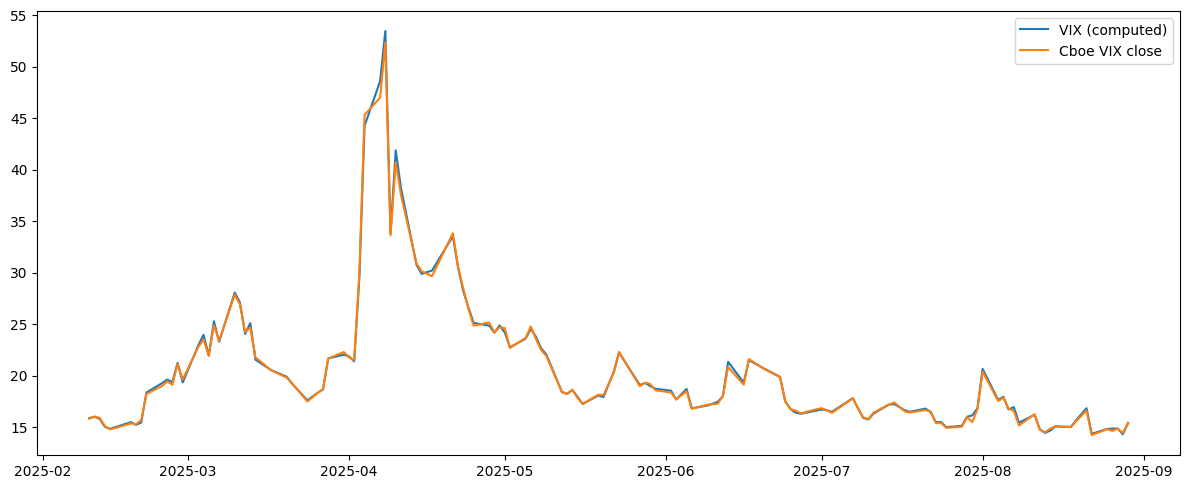

In [ ]:
import matplotlib.pyplot as plt

vix_df = vix_df.copy()
vix_df["date"] = pd.to_datetime(vix_df["date"])
vix_df = vix_df.dropna(subset=["vix"]).sort_values("date")

start_date = vix_df["date"].min().date()
end_date   = vix_df["date"].max().date()

# Cboe VIX close from WRDS
sql = f"""
SELECT date, vix
FROM cboe.cboe
WHERE date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY date
"""
vix_off = db.raw_sql(sql)
vix_off["date"] = pd.to_datetime(vix_off["date"])
vix_off["vix"] = pd.to_numeric(vix_off["vix"], errors="coerce")
vix_off = vix_off.dropna(subset=["vix"]).rename(columns={"vix": "vix_cboe"})

cmp = (
    vix_df[["date", "vix"]]
    .merge(vix_off, on="date", how="inner")
    .sort_values("date")
)

cmp["diff"] = cmp["vix"] - cmp["vix_cboe"]
mae = cmp["diff"].abs().mean()
rmse = float(np.sqrt((cmp["diff"] ** 2).mean()))
corr = float(cmp[["vix", "vix_cboe"]].corr().iloc[0, 1])

print(f"MAE: {mae:.3f}  RMSE: {rmse:.3f}  Corr: {corr:.4f}")

# plot
plt.figure(figsize=(12, 5))
plt.plot(cmp["date"], cmp["vix"], label="VIX (computed)")
plt.plot(cmp["date"], cmp["vix_cboe"], label="Cboe VIX close")
plt.legend()
plt.tight_layout()
plt.show()